In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
!pip install -q datasets tensorflow scikit-learn matplotlib seaborn pillow

In [2]:
from datasets import load_dataset

dataset = load_dataset("PedroSampaio/fruits-360")

print(dataset)

README.md:   0%|          | 0.00/3.58k [00:00<?, ?B/s]

data/train-00000-of-00001-086dc013443c48(…): reconstructing file:   0%|          |  0.00B /  299MB            

data/train-00000-of-00001-086dc013443c48(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-0d294abe3826b2e(…): reconstructing file:   0%|          |  0.00B / 98.3MB            

data/test-00000-of-00001-0d294abe3826b2e(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67690 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22688 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 67690
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 22688
    })
})


In [3]:
labels = dataset["train"].features["label"].names

print("Jumlah kelas:", len(labels))

for i, label in enumerate(labels):
    print(i, label)

Jumlah kelas: 113
0 Apple Braeburn
1 Apple Crimson Snow
2 Apple Golden
3 Apple Granny Smith
4 Apple Pink Lady
5 Apple Red
6 Apple Red Delicious
7 Apple Red Yellow
8 Apricot
9 Avocado
10 Avocado ripe
11 Banana
12 Banana Lady Finger
13 Banana Red
14 Beetroot
15 Blueberry
16 Cactus fruit
17 Cantaloupe
18 Carambula
19 Cauliflower
20 Cherry
21 Cherry Rainier
22 Cherry Wax Black
23 Cherry Wax Red
24 Cherry Wax Yellow
25 Chestnut
26 Clementine
27 Cocos
28 Corn
29 Corn Husk
30 Cucumber Ripe
31 Dates
32 Eggplant
33 Fig
34 Ginger Root
35 Granadilla
36 Grape Blue
37 Grape Pink
38 Grape White
39 Grapefruit Pink
40 Grapefruit White
41 Guava
42 Hazelnut
43 Huckleberry
44 Kaki
45 Kiwi
46 Kohlrabi
47 Kumquats
48 Lemon
49 Lemon Meyer
50 Limes
51 Lychee
52 Mandarine
53 Mango
54 Mango Red
55 Mangostan
56 Maracuja
57 Melon Piel de Sapo
58 Mulberry
59 Nectarine
60 Nectarine Flat
61 Nut Forest
62 Nut Pecan
63 Onion Red
64 Onion Red Peeled
65 Onion White
66 Orange
67 Papaya
68 Passion Fruit
69 Peach
70 Peach

In [4]:
target_classes = [
    "Apple Braeburn",
    "Banana",
    "Orange",
    "Grape Blue",
    "Strawberry"
]

target_ids = [labels.index(x) for x in target_classes]

print("Target classes:")
for i, name in enumerate(target_classes):
    print(i, name, "→", target_ids[i])

Target classes:
0 Apple Braeburn → 0
1 Banana → 11
2 Orange → 66
3 Grape Blue → 36
4 Strawberry → 101


In [5]:
train_all = dataset["train"]
test_all = dataset["test"]

train_5 = train_all.filter(
    lambda example: example["label"] in target_ids
)

test_5 = test_all.filter(
    lambda example: example["label"] in target_ids
)

print("Train:", len(train_5))
print("Test :", len(test_5))

Filter:   0%|          | 0/67690 [00:00<?, ? examples/s]

Filter:   0%|          | 0/22688 [00:00<?, ? examples/s]

Train: 2937
Test : 982


In [7]:
id_mapping = {
    old_id: new_id
    for new_id, old_id in enumerate(target_ids)
}

def remap_label(example):
    example["label"] = id_mapping[example["label"]]
    return example

train_5 = train_5.map(remap_label)
test_5 = test_5.map(remap_label)

print(train_5.features)

Map:   0%|          | 0/2937 [00:00<?, ? examples/s]

Map:   0%|          | 0/982 [00:00<?, ? examples/s]

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden', 'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red', 'Apple Red Delicious', 'Apple Red Yellow', 'Apricot', 'Avocado', 'Avocado ripe', 'Banana', 'Banana Lady Finger', 'Banana Red', 'Beetroot', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Carambula', 'Cauliflower', 'Cherry', 'Cherry Rainier', 'Cherry Wax Black', 'Cherry Wax Red', 'Cherry Wax Yellow', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Corn Husk', 'Cucumber Ripe', 'Dates', 'Eggplant', 'Fig', 'Ginger Root', 'Granadilla', 'Grape Blue', 'Grape Pink', 'Grape White', 'Grapefruit Pink', 'Grapefruit White', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Lemon Meyer', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mango Red', 'Mangostan', 'Maracuja', 'Melon Piel de Sapo', 'Mulberry', 'Nectarine', 'Nectarine Flat', 'Nut Forest', 'Nut Pecan', 'Onion Red', 'Onion Red Peeled', 'Onion Wh

In [8]:
split_data = train_5.train_test_split(
    test_size=0.2,
    seed=42,
    stratify_by_column="label"
)

train_data = split_data["train"]
val_data = split_data["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_5))

Train: 2349
Validation: 588
Test: 982


In [9]:
import os
from PIL import Image

base_dir = "/content/fruits5"

for split in ["train", "val", "test"]:
    for class_name in target_classes:
        os.makedirs(
            f"{base_dir}/{split}/{class_name}",
            exist_ok=True
        )

In [10]:
def save_hf_dataset(hf_dataset, split_name):
    for i, example in enumerate(hf_dataset):
        image = example["image"].convert("RGB")
        label_id = example["label"]
        class_name = target_classes[label_id]

        save_path = (
            f"{base_dir}/{split_name}/"
            f"{class_name}/{i}.jpg"
        )

        image.save(save_path)

    print(split_name, "selesai")

In [11]:
save_hf_dataset(train_data, "train")
save_hf_dataset(val_data, "val")
save_hf_dataset(test_5, "test")

train selesai
val selesai
test selesai


In [12]:
import os

for split in ["train", "val", "test"]:
    print("\n", split.upper())

    for class_name in target_classes:
        folder = f"{base_dir}/{split}/{class_name}"
        count = len(os.listdir(folder))

        print(class_name, ":", count)


 TRAIN
Apple Braeburn : 394
Banana : 392
Orange : 383
Grape Blue : 787
Strawberry : 393

 VAL
Apple Braeburn : 98
Banana : 98
Orange : 96
Grape Blue : 197
Strawberry : 99

 TEST
Apple Braeburn : 164
Banana : 166
Orange : 160
Grape Blue : 328
Strawberry : 164


In [13]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_dir}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_dir}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_dir}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 2349 files belonging to 5 classes.
Found 588 files belonging to 5 classes.
Found 982 files belonging to 5 classes.


In [14]:
print(train_ds.class_names)

['Apple Braeburn', 'Banana', 'Grape Blue', 'Orange', 'Strawberry']


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [17]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9408 - loss: 0.2103 - val_accuracy: 1.0000 - val_loss: 0.0174
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.000

In [21]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.9276 - loss: 0.2210 - val_accuracy: 1.0000 - val_loss: 8.4572e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9911 - loss: 0.0466 - val_accuracy: 1.0000 - val_loss: 5.0448e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9979 - loss: 0.0178 - val_accuracy: 1.0000 - val_loss: 3.0921e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9983 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 2.0363e-04
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 1.3477e-04
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9991 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 9.7707e-05
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.9996 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 7.0458e-05
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 1.0000 - los

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 1.0000 - loss: 3.1444e-05
Test Accuracy: 1.0
Test Loss: 3.144394941045903e-05


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


class_names = [
    "Apple Braeburn",
    "Banana",
    "Grape Blue",
    "Orange",
    "Strawberry"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

Apple Braeburn       1.00      1.00      1.00       164
        Banana       1.00      1.00      1.00       166
    Grape Blue       1.00      1.00      1.00       328
        Orange       1.00      1.00      1.00       160
    Strawberry       1.00      1.00      1.00       164

      accuracy                           1.00       982
     macro avg       1.00      1.00      1.00       982
  weighted avg       1.00      1.00      1.00       982



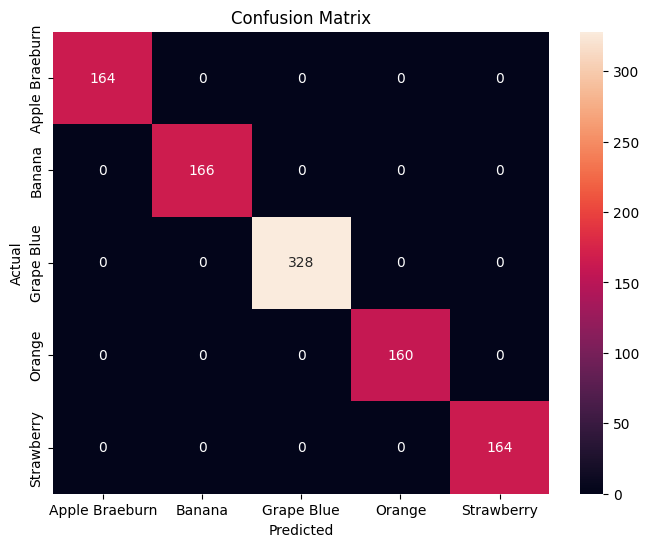

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
model.save("/content/buah_classifier.keras")

In [29]:
!ls -lh /content/buah_classifier.keras

-rw-r--r-- 1 root root 21M Jul 30 04:37 /content/buah_classifier.keras


In [30]:
import json

label_indo = {
    "Apple Braeburn": "APEL",
    "Banana": "PISANG",
    "Grape Blue": "ANGGUR",
    "Orange": "JERUK",
    "Strawberry": "STROBERI"
}

with open("/content/labels.json", "w") as f:
    json.dump(label_indo, f)

In [33]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


In [34]:
from PIL import Image
import numpy as np
import tensorflow as tf

file_name = list(uploaded.keys())[0]

image = Image.open(file_name).convert("RGB")
image = image.resize((224, 224))

img_array = np.array(image)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0]

predicted_index = np.argmax(prediction)
confidence = prediction[predicted_index]

class_name = class_names[predicted_index]

label_indo = {
    "Apple Braeburn": "APEL",
    "Banana": "PISANG",
    "Grape Blue": "ANGGUR",
    "Orange": "JERUK",
    "Strawberry": "STROBERI"
}

hasil = label_indo[class_name]

print("=" * 40)
print("HASIL PREDIKSI")
print("=" * 40)
print(hasil)
print(f"Confidence: {confidence * 100:.2f}%")
print("=" * 40)

HASIL PREDIKSI
APEL
Confidence: 99.42%


In [35]:
from google.colab import files

files.download("/content/buah_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
files.download("/content/labels.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [38]:
model.save_weights("/content/buah_classifier.weights.h5")

In [39]:
from google.colab import files

files.download("/content/buah_classifier.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>